In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantdisease' dataset.
Path to dataset files: /kaggle/input/plantdisease


In [8]:
import os

dataset_path = "/kaggle/input/plantdisease/plantvillage/PlantVillage"
print(os.listdir(dataset_path))  # See the main folders (usually plant types)


['Pepper__bell___Bacterial_spot', 'Potato___healthy', 'Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_Bacterial_spot', 'Tomato_Septoria_leaf_spot', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___healthy', 'Potato___Late_blight', 'Tomato_Late_blight', 'Potato___Early_blight', 'Tomato__Tomato_mosaic_virus']


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = dataset_path  # Point to main folder
img_height, img_width = 224, 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # split 20% for validation
)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # training data
)

val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # validation data
)


Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(15, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,895 (42.61 MB)

 Trainable params: 11,170,895 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 135s 247ms/step - accuracy: 0.2983 - loss: 2.2100 - val_accuracy: 0.6786 - val_loss: 1.0030
Epoch 2/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.6049 - loss: 1.2085 - val_accuracy: 0.7613 - val_loss: 0.7589
Epoch 3/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - accuracy: 0.6724 - loss: 0.9608 - val_accuracy: 0.8144 - val_loss: 0.5864
Epoch 4/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.7319 - loss: 0.7818 - val_accuracy: 0.7965 - val_loss: 0.6033
Epoch 5/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 39s 75ms/step - accuracy: 0.7554 - loss: 0.6941 - val_accuracy: 0.8399 - val_loss: 0.4610
Epoch 6/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.7986 - loss: 0.5852 - val_accuracy: 0.8263 - val_loss: 0.4970
Epoch 7/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - accuracy: 0.8173 - loss: 0.5243 - val_accuracy: 0.8603 - val_loss: 0.4239
Epoch 8/25
517/517 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.8418 - loss: 0.4429 

In [18]:
# Initialize list
class_names = [None] * len(train_generator.class_indices)

# Fill according to indices
for name, idx in train_generator.class_indices.items():
    class_names[idx] = name



In [19]:
from tensorflow.keras.preprocessing import image
import numpy as np

IMG_SIZE = (224, 224)  # Same as your CNN input size

def prepare_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array


In [20]:
img_path = "/content/Septoria_Leaf_Spot_of_Tomato186.jpg"  # Replace with your image path in Colab
img_array = prepare_image(img_path)

preds = model.predict(img_array)
class_idx = np.argmax(preds[0])
prediction = class_names[class_idx]
confidence = float(np.max(preds[0]))

print("Predicted disease:", prediction)
print("Confidence:", round(confidence*100, 2), "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted disease: Pepper__bell___Bacterial_spot
Confidence: 91.7 %


In [21]:
img_path = "/content/images.jpeg"  # Replace with your image path in Colab
img_array = prepare_image(img_path)

preds = model.predict(img_array)
class_idx = np.argmax(preds[0])
prediction = class_names[class_idx]
confidence = float(np.max(preds[0]))

print("Predicted disease:", prediction)
print("Confidence:", round(confidence*100, 2), "%")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Predicted disease: Tomato_Late_blight
Confidence: 100.0 %


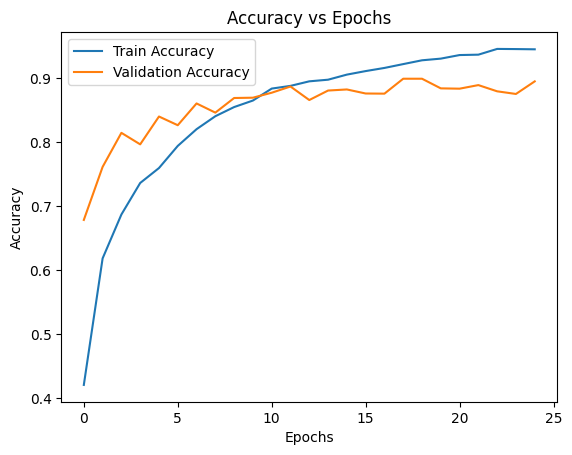

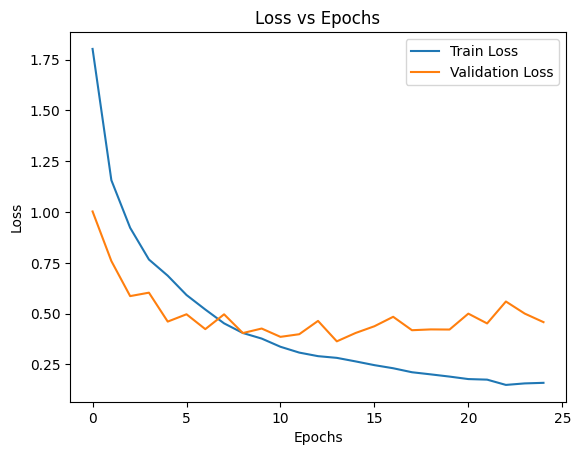

In [22]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [23]:
# Save the model as HDF5
model.save("plant_disease_model.h5")


In [24]:
from google.colab import files

files.download("plant_disease_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>